# UPI Fraud Detection — K-Nearest Neighbors (KNN)


In [1]:
import sys
sys.path.append("../src")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, RocCurveDisplay

from models.evaluate import evaluate_model, print_report, print_summary, plot_confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_SEED = 42
REFERENCE_SIZE = 25_000

X_train = pd.read_csv("../data/processed/X_train_final.csv")
y_train = pd.read_csv("../data/processed/y_train_final.csv")["is_fraud"]
X_test = pd.read_csv("../data/processed/X_test_final.csv")
y_test = pd.read_csv("../data/processed/y_test_final.csv")["is_fraud"]

print("Full train:", X_train.shape, " Test:", X_test.shape)

Full train: (220930, 61)  Test: (30000, 61)


## 1. Build the Reference Set + Internal Validation Split


In [2]:
X_ref = X_train.sample(n=REFERENCE_SIZE, random_state=RANDOM_SEED)
y_ref = y_train.loc[X_ref.index]

X_val_pool = X_train.drop(X_ref.index).sample(n=5000, random_state=RANDOM_SEED)
y_val_pool = y_train.loc[X_val_pool.index]

print("Reference set:", X_ref.shape)
print("Internal validation set:", X_val_pool.shape)

Reference set: (25000, 61)
Internal validation set: (5000, 61)


## 2. Hyperparameter Selection


In [3]:
param_grid = [
    {"n_neighbors": k, "weights": w}
    for k in [3, 5, 7, 9, 11]
    for w in ["uniform", "distance"]
]

results = []
t0 = time.time()
for params in param_grid:
    model = KNeighborsClassifier(n_jobs=-1, **params)
    model.fit(X_ref, y_ref)
    val_pred = model.predict(X_val_pool)
    score = f1_score(y_val_pool, val_pred)
    results.append({**params, "val_f1": score})

print(f"Grid search completed in {time.time() - t0:.1f}s")
results_df = pd.DataFrame(results).sort_values("val_f1", ascending=False)
results_df

Grid search completed in 9.0s


,n_neighbors,weights,val_f1
9,11,distance,0.988409
0,3,uniform,0.987851
1,3,distance,0.987851
7,9,distance,0.987625
8,11,uniform,0.987600
3,5,distance,0.987443
6,9,uniform,0.987418
2,5,uniform,0.987039
5,7,distance,0.986645
4,7,uniform,0.985837


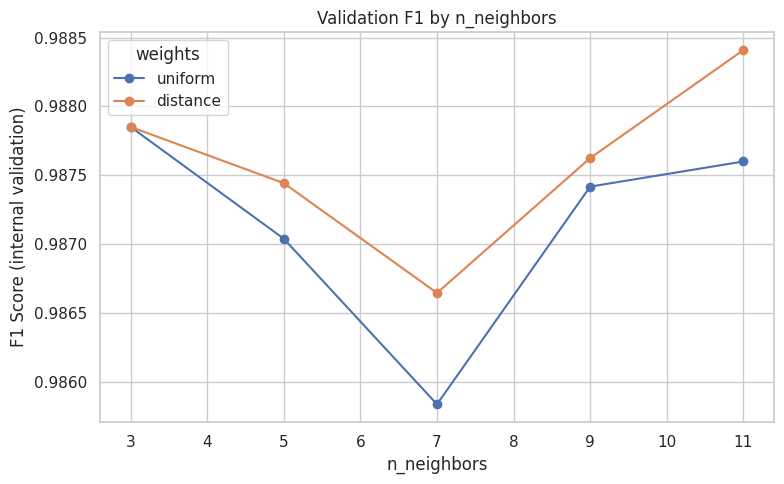

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for weight in ["uniform", "distance"]:
    subset = results_df[results_df["weights"] == weight].sort_values("n_neighbors")
    ax.plot(subset["n_neighbors"], subset["val_f1"], marker="o", label=weight)
ax.set_title("Validation F1 by n_neighbors")
ax.set_xlabel("n_neighbors")
ax.set_ylabel("F1 Score (internal validation)")
ax.legend(title="weights")
plt.tight_layout()
plt.savefig("../reports/figures/24_knn_hyperparameter_search.png", dpi=150)
plt.show()

## 3. Final Model & Test Set Evaluation

In [5]:
best_params = results_df.iloc[0][["n_neighbors", "weights"]].to_dict()
best_params["n_neighbors"] = int(best_params["n_neighbors"])
print("Best params:", best_params)

best_knn = KNeighborsClassifier(n_jobs=-1, **best_params)
best_knn.fit(X_ref, y_ref)

t0 = time.time()
y_pred = best_knn.predict(X_test)
print(f"Prediction over full test set ({len(X_test):,} rows) took {time.time() - t0:.1f}s")

print_report(y_test, y_pred, "KNN (tuned)")
knn_metrics = evaluate_model(best_knn, X_test, y_test, model_name="KNN", save=True)
print_summary(knn_metrics)

Best params: {'n_neighbors': 11, 'weights': 'distance'}


Prediction over full test set (30,000 rows) took 5.1s
=== KNN (tuned) — Classification Report ===
              precision    recall  f1-score   support

    No Fraud       1.00      0.98      0.99     27616
       Fraud       0.79      0.99      0.88      2384

    accuracy                           0.98     30000
   macro avg       0.90      0.98      0.93     30000
weighted avg       0.98      0.98      0.98     30000



Model: KNN
  Accuracy:  0.9788
  Precision: 0.7947
  Recall:    0.9891
  F1 Score:  0.8813
  ROC-AUC:   0.9962


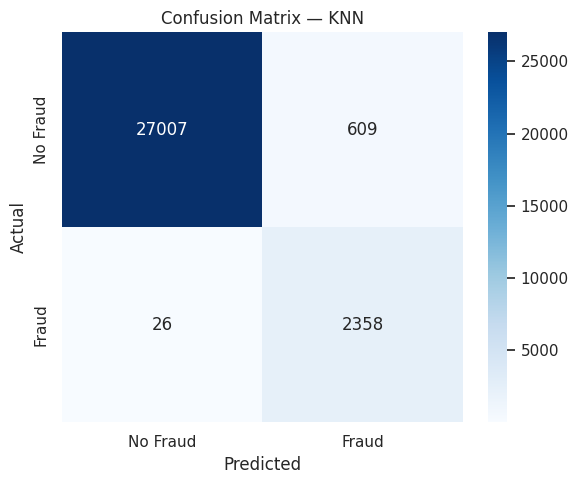

In [6]:
fig, ax = plot_confusion_matrix(knn_metrics, save_path="../reports/figures/25_knn_confusion_matrix.png")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


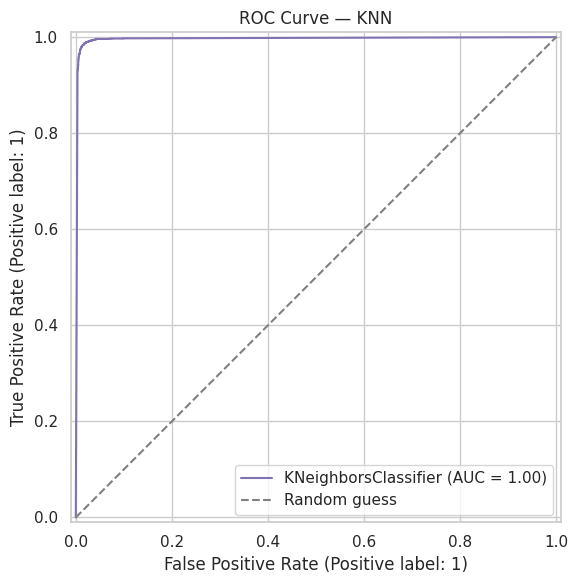

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(best_knn, X_test, y_test, ax=ax, color="#8172B2")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve — KNN")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/26_knn_roc_curve.png", dpi=150)
plt.show()

## 4. Save Model

In [8]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_knn, "../models/knn.pkl")
print("Saved to models/knn.pkl")

Saved to models/knn.pkl
